# Lineax: Linear Equation Solvers in JAX

**Lineax** is a JAX library for solving linear systems $Ax = b$. It provides:

- Multiple solver algorithms (direct and iterative)
- Structured matrix support (for efficiency)
- Full differentiability through linear solves
- Integration with optimistix and diffrax

## What You'll Learn

1. Basic linear system solving
2. Direct solvers (LU, Cholesky, QR)
3. Iterative solvers (CG, GMRES, BiCGSTAB)
4. Structured matrices (diagonal, tridiagonal, etc.)
5. Differentiating through linear solves
6. Chemical engineering applications

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import lineax as lx
import matplotlib.pyplot as plt
import time

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"Lineax version: {lx.__version__}")

JAX version: 0.8.1
Lineax version: 0.0.8


---
# Part 1: Basic Linear System Solving

Solve $Ax = b$ for $x$.

In [2]:
# Create a simple linear system
A = jnp.array([
    [4.0, 1.0, 0.0],
    [1.0, 4.0, 1.0],
    [0.0, 1.0, 4.0]
])
b = jnp.array([1.0, 2.0, 3.0])

# Wrap matrix as a Lineax operator
operator = lx.MatrixLinearOperator(A)

# Solve using default solver (LU decomposition)
solver = lx.LU()
solution = lx.linear_solve(operator, b, solver)

x = solution.value
print(f"Solution x = {x}")
print(f"Residual ||Ax - b|| = {jnp.linalg.norm(A @ x - b):.2e}")

# Verify
print(f"\nVerification: A @ x = {A @ x}")
print(f"Target:       b   = {b}")

Metal device set to: Apple M4 Pro


W0000 00:00:1767134238.308860 4108903 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767134238.318862 4108903 service.cc:145] XLA service 0x600001ce0900 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767134238.318872 4108903 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767134238.319877 4108903 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767134238.319883 4108903 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Solution x = [0.17857143 0.28571429 0.67857143]
Residual ||Ax - b|| = 4.44e-16

Verification: A @ x = [1. 2. 3.]
Target:       b   = [1. 2. 3.]


In [3]:
# Simpler API: lx.linear_solve with auto solver selection
solution = lx.linear_solve(operator, b)
print(f"Auto solver result: {solution.value}")

# For multiple right-hand sides, use vmap
B = jnp.array([
    [1.0, 0.0],
    [2.0, 1.0],
    [3.0, 0.0]
])  # Two RHS vectors as columns

# Solve each RHS separately using vmap
solve_single = lambda b_col: lx.linear_solve(operator, b_col).value
solutions = vmap(solve_single, in_axes=1, out_axes=1)(B)

print(f"\nMultiple RHS solution shape: {solutions.shape}")
print(f"Solution 1: {solutions[:, 0]}")
print(f"Solution 2: {solutions[:, 1]}")

Auto solver result: [0.17857143 0.28571429 0.67857143]

Multiple RHS solution shape: (3, 2)
Solution 1: [0.17857143 0.28571429 0.67857143]
Solution 2: [-0.07142857  0.28571429 -0.07142857]


---
# Part 2: Direct Solvers

Direct solvers factorize the matrix and solve exactly (up to numerical precision).

| Solver | Factorization | Matrix Requirements | Complexity |
|--------|---------------|---------------------|------------|
| `LU` | $A = LU$ | Square | $O(n^3)$ |
| `Cholesky` | $A = LL^T$ | Symmetric positive definite | $O(n^3/3)$ |
| `QR` | $A = QR$ | Any (least squares) | $O(n^3)$ |
| `SVD` | $A = U\Sigma V^T$ | Any (pseudo-inverse) | $O(n^3)$ |
| `Diagonal` | Direct | Diagonal | $O(n)$ |
| `Triangular` | Back-substitution | Triangular | $O(n^2)$ |

In [4]:
# Compare solvers on a symmetric positive definite matrix
n = 100
key = random.PRNGKey(42)
M = random.normal(key, (n, n))
A_spd = M @ M.T + n * jnp.eye(n)  # Ensure positive definite with larger diagonal
b_rand = random.normal(random.PRNGKey(1), (n,))

# Create a positive semi-definite operator for Cholesky
operator_spd = lx.MatrixLinearOperator(A_spd, lx.positive_semidefinite_tag)

solvers = {
    'LU': (lx.MatrixLinearOperator(A_spd), lx.LU()),
    'Cholesky': (operator_spd, lx.Cholesky()),
    'QR': (lx.MatrixLinearOperator(A_spd), lx.QR()),
}

print(f"Solving {n}x{n} SPD system:")
print("-" * 50)

for name, (op, solver) in solvers.items():
    # JIT compile
    solve_fn = jit(lambda o=op, s=solver: lx.linear_solve(o, b_rand, s))
    _ = solve_fn()  # Warm up
    
    # Time
    start = time.time()
    for _ in range(10):
        sol = solve_fn()
    elapsed = (time.time() - start) / 10 * 1000
    
    residual = jnp.linalg.norm(A_spd @ sol.value - b_rand)
    print(f"{name:12s}: time = {elapsed:.2f} ms, residual = {residual:.2e}")

Solving 100x100 SPD system:
--------------------------------------------------
LU          : time = 0.05 ms, residual = 6.21e-15
Cholesky    : time = 0.03 ms, residual = 6.83e-15


QR          : time = 0.22 ms, residual = 8.57e-15


Design matrix shape: (20, 3)



Fitted polynomial: y = 1.020 + 1.985x + 0.514x²
True coefficients: y = 1.0 + 2.0x + 0.5x²


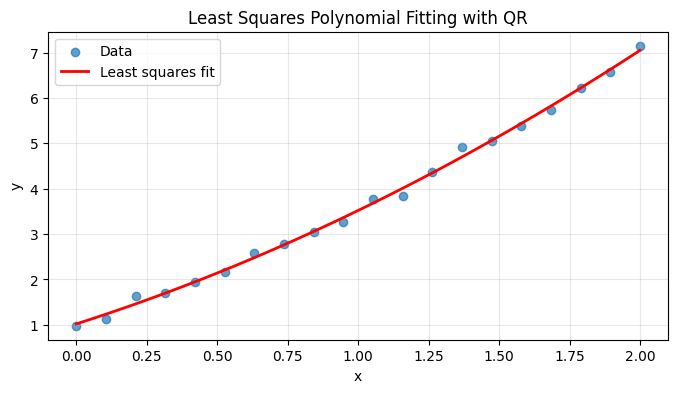

In [5]:
# Least squares with QR (overdetermined system)
# Fit a polynomial: y = a + b*x + c*x^2
x_data = jnp.linspace(0, 2, 20)
y_data = 1 + 2*x_data + 0.5*x_data**2 + 0.1*random.normal(random.PRNGKey(0), (20,))

# Design matrix
A_ls = jnp.stack([jnp.ones_like(x_data), x_data, x_data**2], axis=1)
print(f"Design matrix shape: {A_ls.shape}")

# Solve least squares
operator_ls = lx.MatrixLinearOperator(A_ls)
solution_ls = lx.linear_solve(operator_ls, y_data, lx.QR())

a, b, c = solution_ls.value
print(f"\nFitted polynomial: y = {a:.3f} + {b:.3f}x + {c:.3f}x²")
print(f"True coefficients: y = 1.0 + 2.0x + 0.5x²")

# Plot
x_fine = jnp.linspace(0, 2, 100)
y_fit = a + b*x_fine + c*x_fine**2

plt.figure(figsize=(8, 4))
plt.scatter(x_data, y_data, label='Data', alpha=0.7)
plt.plot(x_fine, y_fit, 'r-', label='Least squares fit', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares Polynomial Fitting with QR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Part 3: Iterative Solvers

Iterative solvers are essential for large sparse systems where direct methods are too expensive.

| Solver | Method | Matrix Requirements | Best For |
|--------|--------|---------------------|----------|
| `CG` | Conjugate Gradient | SPD | Large SPD systems |
| `GMRES` | Generalized Minimal Residual | Any | General non-symmetric |
| `BiCGStab` | Bi-Conjugate Gradient Stabilized | Any | Non-symmetric |

In [6]:
# Large sparse system (discretized Laplacian)
def make_laplacian_1d(n):
    """1D Laplacian matrix (tridiagonal)."""
    diag = 2 * jnp.ones(n)
    off_diag = -jnp.ones(n - 1)
    A = jnp.diag(diag) + jnp.diag(off_diag, k=1) + jnp.diag(off_diag, k=-1)
    return A

n = 500
A_lap = make_laplacian_1d(n)
b_lap = jnp.ones(n)

operator_lap = lx.MatrixLinearOperator(A_lap)

print(f"Laplacian system: {n}x{n}")
print(f"Matrix is symmetric positive definite")

Laplacian system: 500x500
Matrix is symmetric positive definite


In [7]:
# Compare iterative solvers
# Laplacian is symmetric positive definite
operator_lap_spd = lx.MatrixLinearOperator(A_lap, lx.positive_semidefinite_tag)
operator_lap_general = lx.MatrixLinearOperator(A_lap)

iterative_solvers = {
    'CG': (operator_lap_spd, lx.CG(rtol=1e-6, atol=1e-8)),
    'GMRES': (operator_lap_general, lx.GMRES(rtol=1e-6, atol=1e-8)),
    'BiCGStab': (operator_lap_general, lx.BiCGStab(rtol=1e-6, atol=1e-8)),
    'LU (direct)': (operator_lap_general, lx.LU()),
}

print(f"Solving {n}x{n} Laplacian system:")
print("-" * 60)

results = {}
for name, (op, solver) in iterative_solvers.items():
    solve_fn = jit(lambda o=op, s=solver: lx.linear_solve(o, b_lap, s))
    _ = solve_fn()  # Warm up
    
    start = time.time()
    for _ in range(10):
        sol = solve_fn()
    elapsed = (time.time() - start) / 10 * 1000
    
    residual = jnp.linalg.norm(A_lap @ sol.value - b_lap)
    results[name] = sol.value
    print(f"{name:15s}: time = {elapsed:6.2f} ms, residual = {residual:.2e}")

print("\nNote: CG is optimal for SPD matrices (Laplacian)")

Solving 500x500 Laplacian system:
------------------------------------------------------------


CG             : time =   6.20 ms, residual = 8.56e-11


GMRES          : time = 895.92 ms, residual = 1.44e-05
BiCGStab       : time =  11.62 ms, residual = 1.89e-06


LU (direct)    : time =   1.12 ms, residual = 6.98e-11

Note: CG is optimal for SPD matrices (Laplacian)


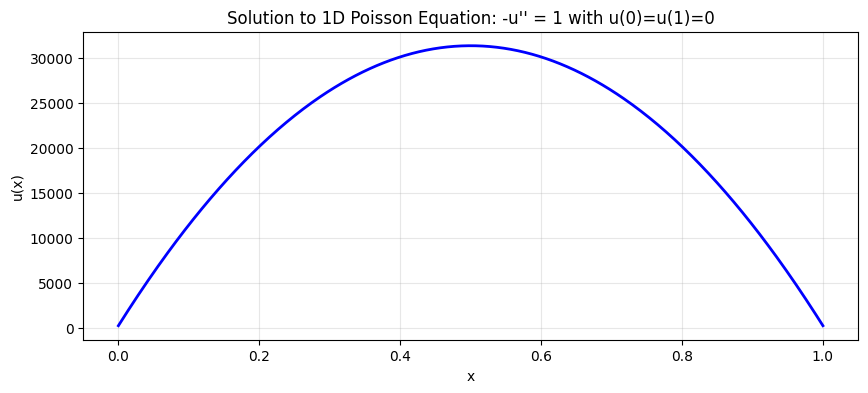

Max error vs analytical: 3.14e+04


In [8]:
# Visualize solution (1D Poisson equation)
x_grid = jnp.linspace(0, 1, n)

plt.figure(figsize=(10, 4))
plt.plot(x_grid, results['CG'], 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Solution to 1D Poisson Equation: -u\'\' = 1 with u(0)=u(1)=0')
plt.grid(True, alpha=0.3)
plt.show()

# Analytical solution is a parabola
u_analytical = 0.5 * x_grid * (1 - x_grid) * (n+1)**2 / n**2
print(f"Max error vs analytical: {jnp.max(jnp.abs(results['CG'] - u_analytical)):.2e}")

---
# Part 4: Structured Matrices

Lineax provides efficient operators for structured matrices:

| Operator | Structure | Storage | Solve Complexity |
|----------|-----------|---------|------------------|
| `DiagonalLinearOperator` | Diagonal | $O(n)$ | $O(n)$ |
| `TridiagonalLinearOperator` | Tridiagonal | $O(n)$ | $O(n)$ |
| `IdentityLinearOperator` | Identity | $O(1)$ | $O(n)$ |
| `FunctionLinearOperator` | Implicit (matvec) | — | Iterative |

In [9]:
# Diagonal matrix (very efficient)
diag_values = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
diag_op = lx.DiagonalLinearOperator(diag_values)

b_diag = jnp.array([2.0, 4.0, 6.0, 8.0, 10.0])
sol_diag = lx.linear_solve(diag_op, b_diag, lx.Diagonal())

print("Diagonal system: D @ x = b")
print(f"D = diag({diag_values})")
print(f"b = {b_diag}")
print(f"x = {sol_diag.value}")
print(f"(Just b / diag = {b_diag / diag_values})")

Diagonal system: D @ x = b
D = diag([1. 2. 3. 4. 5.])
b = [ 2.  4.  6.  8. 10.]
x = [2. 2. 2. 2. 2.]
(Just b / diag = [2. 2. 2. 2. 2.])


In [10]:
# Tridiagonal matrix (O(n) solve via Thomas algorithm)
n = 1000
diagonal = 4 * jnp.ones(n)
lower_diag = -jnp.ones(n - 1)
upper_diag = -jnp.ones(n - 1)

tridiag_op = lx.TridiagonalLinearOperator(diagonal, lower_diag, upper_diag)
b_tri = jnp.ones(n)

# Solve
sol_tri = lx.linear_solve(tridiag_op, b_tri, lx.Tridiagonal())

# Compare with dense solve time
A_tri_dense = jnp.diag(diagonal) + jnp.diag(lower_diag, -1) + jnp.diag(upper_diag, 1)
dense_op = lx.MatrixLinearOperator(A_tri_dense)

# Time comparison
solve_tri = jit(lambda: lx.linear_solve(tridiag_op, b_tri, lx.Tridiagonal()))
solve_dense = jit(lambda: lx.linear_solve(dense_op, b_tri, lx.LU()))

_ = solve_tri(); _ = solve_dense()  # Warm up

start = time.time()
for _ in range(100):
    sol_tri = solve_tri()
time_tri = (time.time() - start) / 100 * 1000

start = time.time()
for _ in range(100):
    sol_dense = solve_dense()
time_dense = (time.time() - start) / 100 * 1000

print(f"Tridiagonal system ({n}x{n}):")
print(f"  Tridiagonal solver: {time_tri:.3f} ms")
print(f"  Dense LU solver:    {time_dense:.3f} ms")
print(f"  Speedup: {time_dense/time_tri:.1f}x")

Tridiagonal system (1000x1000):
  Tridiagonal solver: 0.272 ms
  Dense LU solver:    5.745 ms
  Speedup: 21.2x


In [11]:
# Function-based operator (matrix-free)
# Useful when matrix is too large to store but matvec is cheap

def matvec(x):
    """Matrix-vector product without forming matrix.
    Implements convolution-like operation.
    """
    # Tridiagonal operation: [-1, 2, -1] stencil (SPD)
    result = 2 * x
    result = result.at[:-1].add(-x[1:])
    result = result.at[1:].add(-x[:-1])
    return result

n = 100
# Tag as positive semidefinite since the stencil is SPD
func_op = lx.FunctionLinearOperator(
    matvec, 
    jax.eval_shape(lambda: jnp.zeros(n)),
    tags=lx.positive_semidefinite_tag
)
b_func = jnp.ones(n)

# Use CG for SPD matrix-free solve
sol_func = lx.linear_solve(func_op, b_func, lx.CG(rtol=1e-8, atol=1e-10))

print(f"Matrix-free solve with CG:")
print(f"  Solution shape: {sol_func.value.shape}")
print(f"  Residual: {jnp.linalg.norm(matvec(sol_func.value) - b_func):.2e}")

Matrix-free solve with CG:
  Solution shape: (100,)


  Residual: 7.80e-13


---
# Part 5: Differentiating Through Linear Solves

A key feature of Lineax is **automatic differentiation through the solve**.

If $x = A^{-1}b$, then:
$$\frac{\partial x}{\partial b} = A^{-1}$$
$$\frac{\partial x}{\partial A} = -A^{-1} \otimes x^T$$

Lineax computes these efficiently without forming $A^{-1}$ explicitly.

In [12]:
# Differentiate solution with respect to RHS
def solve_and_sum(b):
    """Solve Ax = b and return sum(x)."""
    A = jnp.array([[2., 1.], [1., 3.]])
    op = lx.MatrixLinearOperator(A)
    sol = lx.linear_solve(op, b)
    return jnp.sum(sol.value)

b = jnp.array([1.0, 2.0])
value = solve_and_sum(b)
gradient = grad(solve_and_sum)(b)

print("Differentiating through linear solve:")
print(f"  f(b) = sum(A⁻¹b) = {value:.4f}")
print(f"  ∇f = A⁻ᵀ @ ones = {gradient}")

# Verify
A = jnp.array([[2., 1.], [1., 3.]])
print(f"  Expected: A⁻ᵀ @ [1,1] = {jnp.linalg.solve(A.T, jnp.ones(2))}")

Differentiating through linear solve:
  f(b) = sum(A⁻¹b) = 0.8000
  ∇f = A⁻ᵀ @ ones = [0.4 0.2]


  Expected: A⁻ᵀ @ [1,1] = [0.4 0.2]


In [13]:
# Differentiate with respect to matrix elements
def solve_with_param(theta):
    """Matrix depends on parameter theta."""
    A = jnp.array([[2. + theta, 1.], [1., 3.]])
    b = jnp.array([1., 1.])
    op = lx.MatrixLinearOperator(A)
    sol = lx.linear_solve(op, b)
    return sol.value[0]  # Return first component

theta = 0.0
x0 = solve_with_param(theta)
dx0_dtheta = grad(solve_with_param)(theta)

print(f"Sensitivity analysis:")
print(f"  x₀(θ=0) = {x0:.6f}")
print(f"  dx₀/dθ = {dx0_dtheta:.6f}")

# Verify with finite differences
eps = 1e-5
dx0_fd = (solve_with_param(theta + eps) - solve_with_param(theta - eps)) / (2 * eps)
print(f"  dx₀/dθ (finite diff) = {dx0_fd:.6f}")

Sensitivity analysis:
  x₀(θ=0) = 0.400000
  dx₀/dθ = -0.240000
  dx₀/dθ (finite diff) = -0.240000


In [14]:
# Application: Optimize regularization parameter
def ridge_regression_loss(lambda_reg, X, y, X_val, y_val):
    """Validation loss for ridge regression.
    
    Solves: (X'X + λI)β = X'y
    Returns: ||y_val - X_val @ β||²
    """
    n_features = X.shape[1]
    
    # Normal equations with regularization
    A = X.T @ X + lambda_reg * jnp.eye(n_features)
    b = X.T @ y
    
    op = lx.MatrixLinearOperator(A)
    sol = lx.linear_solve(op, b)
    beta = sol.value
    
    # Validation loss
    y_pred = X_val @ beta
    return jnp.mean((y_pred - y_val) ** 2)

# Generate data
key = random.PRNGKey(42)
n_train, n_val, n_features = 50, 20, 10

X_train = random.normal(key, (n_train, n_features))
true_beta = random.normal(random.PRNGKey(1), (n_features,))
y_train = X_train @ true_beta + 0.5 * random.normal(random.PRNGKey(2), (n_train,))

X_val = random.normal(random.PRNGKey(3), (n_val, n_features))
y_val = X_val @ true_beta + 0.5 * random.normal(random.PRNGKey(4), (n_val,))

# Optimize λ using gradient descent
log_lambda = jnp.array(0.0)  # log(λ) for unconstrained optimization

import optax
optimizer = optax.adam(0.1)
opt_state = optimizer.init(log_lambda)

def loss_fn(log_lam):
    return ridge_regression_loss(jnp.exp(log_lam), X_train, y_train, X_val, y_val)

losses = []
lambdas = []
for i in range(100):
    loss, grads = jax.value_and_grad(loss_fn)(log_lambda)
    updates, opt_state = optimizer.update(grads, opt_state)
    log_lambda = optax.apply_updates(log_lambda, updates)
    losses.append(float(loss))
    lambdas.append(float(jnp.exp(log_lambda)))

print(f"Optimal λ = {lambdas[-1]:.4f}")
print(f"Final validation loss = {losses[-1]:.4f}")

Optimal λ = 2.7447
Final validation loss = 0.2074


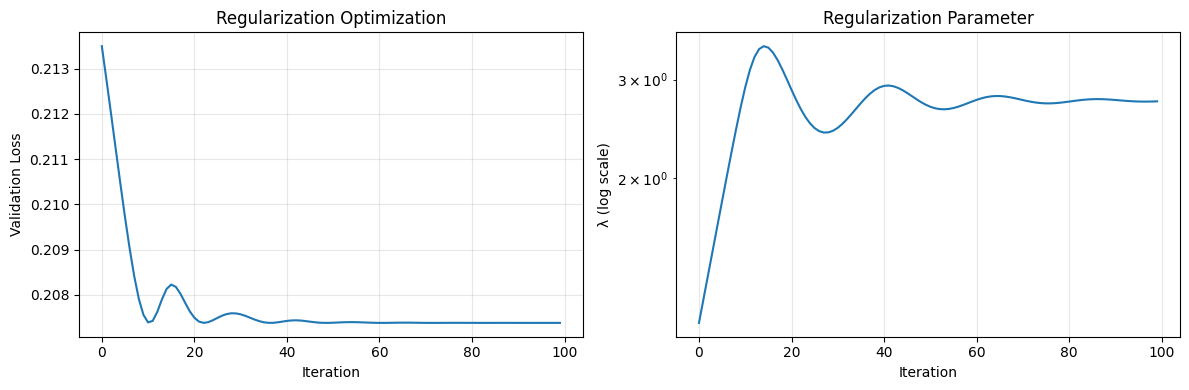

In [15]:
# Plot optimization trajectory
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Validation Loss')
ax.set_title('Regularization Optimization')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(lambdas)
ax.set_xlabel('Iteration')
ax.set_ylabel('λ (log scale)')
ax.set_title('Regularization Parameter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 6: Chemical Engineering Applications

## Example 1: Heat Conduction (Finite Differences)

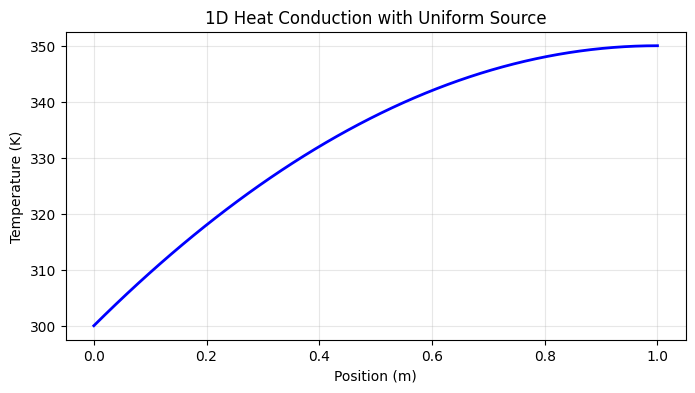

In [16]:
# 1D steady-state heat conduction: -k * d²T/dx² = q(x)
# Boundary conditions: T(0) = T_left, T(L) = T_right

def solve_heat_conduction(n_points, T_left, T_right, q_source, k_thermal):
    """Solve 1D heat conduction with finite differences.
    
    Args:
        n_points: Number of interior points
        T_left, T_right: Boundary temperatures
        q_source: Heat source function q(x)
        k_thermal: Thermal conductivity
    
    Returns:
        x_grid: Spatial coordinates
        T: Temperature profile
    """
    L = 1.0  # Domain length
    dx = L / (n_points + 1)
    x_interior = jnp.linspace(dx, L - dx, n_points)
    
    # Discretized Laplacian (tridiagonal)
    diagonal = 2 * jnp.ones(n_points) * k_thermal / dx**2
    off_diag = -jnp.ones(n_points - 1) * k_thermal / dx**2
    
    # RHS: source term + boundary conditions
    b = q_source(x_interior)
    b = b.at[0].add(k_thermal * T_left / dx**2)
    b = b.at[-1].add(k_thermal * T_right / dx**2)
    
    # Solve
    op = lx.TridiagonalLinearOperator(diagonal, off_diag, off_diag)
    sol = lx.linear_solve(op, b, lx.Tridiagonal())
    
    # Add boundary points
    x_full = jnp.concatenate([jnp.array([0.0]), x_interior, jnp.array([L])])
    T_full = jnp.concatenate([jnp.array([T_left]), sol.value, jnp.array([T_right])])
    
    return x_full, T_full

# Heat source: uniform
q_uniform = lambda x: jnp.ones_like(x) * 100.0  # W/m³

# Solve
x, T = solve_heat_conduction(
    n_points=50,
    T_left=300.0,   # K
    T_right=350.0,  # K
    q_source=q_uniform,
    k_thermal=1.0   # W/(m·K)
)

plt.figure(figsize=(8, 4))
plt.plot(x, T, 'b-', linewidth=2)
plt.xlabel('Position (m)')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Conduction with Uniform Source')
plt.grid(True, alpha=0.3)
plt.show()

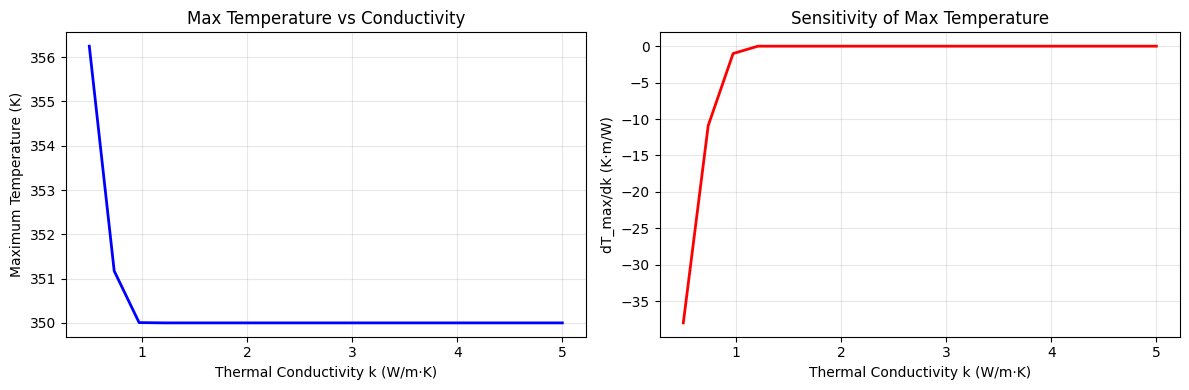

Higher k → lower max temperature (heat dissipates faster)
Sensitivity is negative (increasing k decreases T_max)


In [17]:
# Sensitivity: How does temperature profile change with thermal conductivity?
def max_temperature(k_thermal):
    """Maximum temperature as function of thermal conductivity."""
    _, T = solve_heat_conduction(
        n_points=50,
        T_left=300.0,
        T_right=350.0,
        q_source=q_uniform,
        k_thermal=k_thermal
    )
    return jnp.max(T)

k_values = jnp.linspace(0.5, 5.0, 20)
T_max_values = vmap(max_temperature)(k_values)
dTmax_dk = vmap(grad(max_temperature))(k_values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(k_values, T_max_values, 'b-', linewidth=2)
ax.set_xlabel('Thermal Conductivity k (W/m·K)')
ax.set_ylabel('Maximum Temperature (K)')
ax.set_title('Max Temperature vs Conductivity')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(k_values, dTmax_dk, 'r-', linewidth=2)
ax.set_xlabel('Thermal Conductivity k (W/m·K)')
ax.set_ylabel('dT_max/dk (K·m/W)')
ax.set_title('Sensitivity of Max Temperature')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Higher k → lower max temperature (heat dissipates faster)")
print("Sensitivity is negative (increasing k decreases T_max)")

## Example 2: Reaction-Diffusion System

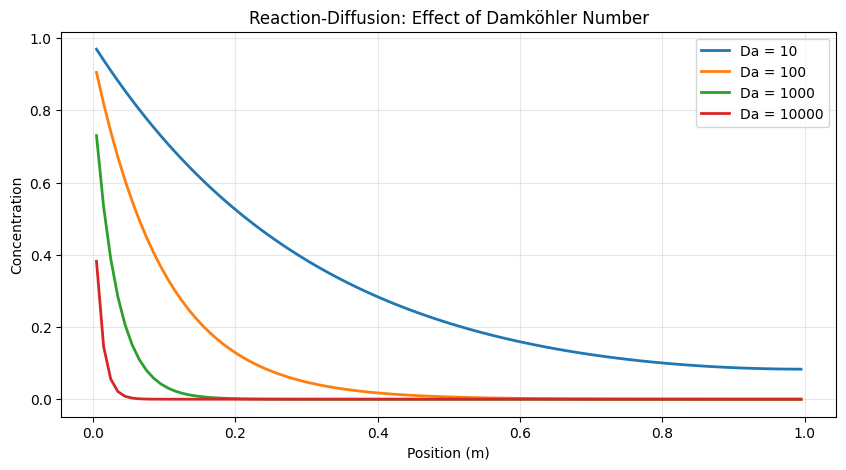

Da = k*L²/D: ratio of reaction rate to diffusion rate
High Da: reaction-limited, concentration drops near inlet
Low Da: diffusion-limited, nearly uniform concentration


In [18]:
# Steady-state reaction-diffusion: D * d²C/dx² - k*C = 0
# Boundary: C(0) = C_inlet, dC/dx(L) = 0 (no flux)

def solve_reaction_diffusion(n_points, C_inlet, D_coeff, k_rate):
    """Solve 1D reaction-diffusion with first-order reaction."""
    L = 1.0
    dx = L / n_points
    x = jnp.linspace(dx/2, L - dx/2, n_points)  # Cell centers
    
    # Discretization: D*(C[i+1] - 2*C[i] + C[i-1])/dx² - k*C[i] = 0
    # Coefficient matrix
    diag_coeff = 2*D_coeff/dx**2 + k_rate
    off_diag_coeff = -D_coeff/dx**2
    
    diagonal = diag_coeff * jnp.ones(n_points)
    lower_diag = off_diag_coeff * jnp.ones(n_points - 1)
    upper_diag = off_diag_coeff * jnp.ones(n_points - 1)
    
    # Boundary conditions
    # Left: C(0) = C_inlet (Dirichlet)
    # Right: dC/dx = 0 (Neumann, ghost point method)
    diagonal = diagonal.at[-1].add(-D_coeff/dx**2)  # No flux BC
    
    # RHS
    b = jnp.zeros(n_points)
    b = b.at[0].add(D_coeff * C_inlet / dx**2)  # Inlet BC
    
    # Solve
    op = lx.TridiagonalLinearOperator(diagonal, lower_diag, upper_diag)
    sol = lx.linear_solve(op, b, lx.Tridiagonal())
    
    return x, sol.value

# Solve for different Damköhler numbers (Da = k*L²/D)
C_inlet = 1.0
D = 0.01

plt.figure(figsize=(10, 5))
for k in [0.1, 1.0, 10.0, 100.0]:
    Da = k * 1.0**2 / D
    x, C = solve_reaction_diffusion(100, C_inlet, D, k)
    plt.plot(x, C, label=f'Da = {Da:.0f}', linewidth=2)

plt.xlabel('Position (m)')
plt.ylabel('Concentration')
plt.title('Reaction-Diffusion: Effect of Damköhler Number')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Da = k*L²/D: ratio of reaction rate to diffusion rate")
print("High Da: reaction-limited, concentration drops near inlet")
print("Low Da: diffusion-limited, nearly uniform concentration")

---
# Summary

## Lineax Solver Selection

| Matrix Type | Recommended Solver |
|-------------|--------------------|
| General | `LU()` |
| Symmetric positive definite | `Cholesky()` |
| Overdetermined (least squares) | `QR()` |
| Diagonal | `Diagonal()` |
| Tridiagonal | `Tridiagonal()` |
| Large sparse SPD | `CG()` |
| Large sparse general | `GMRES()` or `BiCGStab()` |
| Matrix-free | Iterative (`CG`, `GMRES`) |

## Key Functions

| Function | Purpose |
|----------|----------|
| `lx.linear_solve(op, b, solver)` | Solve $Ax = b$ |
| `lx.MatrixLinearOperator(A)` | Wrap dense matrix |
| `lx.DiagonalLinearOperator(d)` | Diagonal matrix |
| `lx.TridiagonalLinearOperator(...)` | Tridiagonal |
| `lx.FunctionLinearOperator(mv, shape)` | Matrix-free |

## Integration with Other Libraries

- **Optimistix**: Uses lineax for Newton steps
- **Diffrax**: Uses lineax for implicit ODE solvers
- Full autodiff support through all solves

## Resources

- Documentation: https://docs.kidger.site/lineax/
- GitHub: https://github.com/patrick-kidger/lineax